# NAVI: Spatial niche discovery on custom H5AD

Pipeline:
1. Train NAVI → extract `X_z_cell`, `X_z_spatial`, `X_z_joint`
2. Sanity-check embeddings (sample mixing, sample predictability)
3. Aggregate `X_z_joint` over spatial neighbours (cellcharter)
4. GMM niche discovery with BIC/AIC model selection
5. Validate niches are cross-sample (not sample-specific artefacts)
6. Visualise niches on tissue sections
7. Differential niche abundance between samples

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

from navi import NAVI

SEED = 7
torch.manual_seed(SEED)
sc.settings.verbosity = 1

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUT_DIR = PROJECT_ROOT / "output" / "niche-analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH    = Path("/Users/christoffer/work/karolinska/development/baloMS/data/baloMS-nuclei-clustered-balo.h5ad")
OUTPUT_H5AD  = OUT_DIR / "navi-with-latents.h5ad"
METRICS_CSV  = OUT_DIR / "embedding-metrics.csv"
NICHE_CSV    = OUT_DIR / "niche-abundance.csv"
CKPT_DIR     = str(OUT_DIR / "checkpoints")

assert DATA_PATH.exists(), f"Missing input: {DATA_PATH}"
print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUT_DIR}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root : /Users/christoffer/work/karolinska/development/NAVI
Output dir   : /Users/christoffer/work/karolinska/development/NAVI/output/niche-analysis
MPS available: True
CUDA available: False


## Load data

In [2]:
adata = sc.read_h5ad(DATA_PATH)
print(adata)

for key in ["sample_id"]:
    assert key in adata.obs, f"Missing obs key: {key}"
assert "spatial" in adata.obsm, "Missing obsm['spatial']"

print("Counts source :", "layers['counts']" if "counts" in adata.layers else "X")
print("Samples       :", adata.obs["sample_id"].nunique())
print(adata.obs["sample_id"].value_counts().to_string())

AnnData object with n_obs × n_vars = 64191 × 4907
    obs: 'cell_id_orig', 'x_centroid', 'y_centroid', 'nucleus_area', 'n_genes_by_counts', 'total_counts', 'n_counts', 'sample_id', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'gmm_mana_5', 'gmm_mana_8', 'gmm_mana_10', 'gmm_mana_12', 'gmm_mana_15', 'gmm_mana_20', 'gmm_mana_30'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'X_mana_gauss_params', 'gmm_mana_10_colors', 'gmm_mana_20_colors', 'gmm_mana_30_colors', 'gmm_mana_5_colors', 'gmm_mana_8_colors', 'hvg', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1', 'leiden_1.5', 'leiden_1.5_colors', 'leiden_1_colors', 'leiden_2', 'leiden_2.5', 'leiden_2.5_colors', 'leiden_2_colors', 'leiden_3', 'leiden_3.5', 'leiden_3.5_colors', 'leiden_3_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial_neighbors', 'umap'
    obsm: 'X_mana_gauss', 'X_pca', 'X_scVI', 'X_umap', 'spatial'
    varm: 'PCs'
    

## Train NAVI

Key settings:
- `normalize_recon_by_genes=False` — keeps reconstruction loss on the same scale as KL/adversarial terms. Without this, KL dominates and the posterior collapses.
- `lambda_adv=1.0` — keeps z_cell sample-agnostic via gradient reversal.
- `lambda_adv_joint=0.0` — z_spatial is *allowed* to vary by sample. Different disease stages have different tissue organisation; that variation is biology, not batch effect.
- `film_scale=0.3` — light FiLM modulation for cross-sample calibration without dominating the spatial representation.
- `patience=30` — early stopping prevents the spatial encoder from memorising tissue geometry (seen at 500 epochs: spiral artefact).
- `max_epochs=300` — a ceiling, not a target; early stopping will fire well before this on most datasets.

In [3]:
if torch.backends.mps.is_available():
    accelerator = "mps"
elif torch.cuda.is_available():
    accelerator = "gpu"
else:
    accelerator = "cpu"

# FiLM grouping: use condition/timepoint if available, otherwise one shared group.
if "condition" in adata.obs.columns:
    adata.obs["film_group"] = adata.obs["condition"].astype(str)
elif "timepoint" in adata.obs.columns:
    adata.obs["film_group"] = adata.obs["timepoint"].astype(str)
else:
    adata.obs["film_group"] = "global"
film_key = "film_group"

print(f"Accelerator  : {accelerator}")
print(f"FiLM key     : {film_key}")
print(f"FiLM groups  : {adata.obs[film_key].value_counts().to_dict()}")

model = NAVI(
    sample_key="sample_id",
    film_key=film_key,
    spatial_key="spatial",
    counts_layer="counts",
    k_neighbors=15,
    n_latent_cell=32,
    n_latent_spatial=32,
    training_mode="joint",
    normalize_recon_by_genes=False,
    lambda_adv=1.0,
    lambda_adv_joint=0.0,
    lambda_film_reg=1e-2,
    film_scale=0.3,
    beta1=1.0,
    beta2=0.5,
    kl_warmup_epochs=5,
    kl_ramp_epochs=20,
    max_epochs=300,
    patience=30,           # stop when train_loss doesn't improve by >1e-4 for 30 epochs
    checkpoint_dir=CKPT_DIR,
    accelerator=accelerator,
    devices=1,
    seed=SEED,
)

model.fit(adata)
latents = model.get_latent(adata)
print({k: v.shape for k, v in latents.items()})

Accelerator  : mps
FiLM key     : film_group
FiLM groups  : {'global': 64191}


Seed set to 7


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                 ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ cell_encoder         │ CellEncoder         │  1.3 M │ train │     0 │
│ 1 │ spatial_encoder      │ SpatialEncoder      │ 54.6 K │ train │     0 │
│ 2 │ sample_embedding     │ SampleEmbedding     │  1.1 K │ train │     0 │
│ 3 │ decoder              │ NBDecoder           │  647 K │ train │     0 │
│ 4 │ gradient_reversal    │ GradientReversal    │      0 │ train │     0 │
│ 5 │ sample_discriminator │ SampleDiscriminator │ 12.6 K │ train │     0 │
│ 6 │ joint_discriminator  │ SampleDiscriminator │ 16.7 K │ train │     0 │
└───┴──────────────────────┴─────────────────────┴────────┴───────┴───────┘

...

Metric train_loss improved by 0.107 >= min_delta = 0.0001. New best score: 1133.127


Metric train_loss improved by 0.004 >= min_delta = 0.0001. New best score: 1133.124


Metric train_loss improved by 0.080 >= min_delta = 0.0001. New best score: 1133.043


Metric train_loss improved by 0.200 >= min_delta = 0.0001. New best score: 1132.843
`Trainer.fit` stopped: `max_epochs=300` reached.


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
{'z_cell': (64191, 32), 'z_spatial': (64191, 32), 'z_joint': (64191, 64)}


## Sanity checks

- **z_cell / z_spatial correlation** — should be low (independent axes).
- **Sample predictability** — a linear classifier on z_cell should perform near chance (sample-agnostic). z_spatial may be somewhat predictable (expected: different tissue organisation per condition).

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

sample_labels = adata.obs["sample_id"].to_numpy()
chance = 1.0 / len(np.unique(sample_labels))

corr = np.corrcoef(latents["z_cell"].flatten(), latents["z_spatial"].flatten())[0, 1]
print(f"z_cell / z_spatial correlation : {corr:.3f}  (want: near 0)")

clf = LogisticRegression(max_iter=1000, random_state=SEED)
rng = np.random.default_rng(SEED)
idx = rng.choice(len(sample_labels), size=min(10000, len(sample_labels)), replace=False)

score_cell    = cross_val_score(clf, latents["z_cell"][idx],    sample_labels[idx], cv=5).mean()
score_spatial = cross_val_score(clf, latents["z_spatial"][idx], sample_labels[idx], cv=5).mean()
score_joint   = cross_val_score(clf, latents["z_joint"][idx],   sample_labels[idx], cv=5).mean()

print(f"\nSample predictability (chance = {chance:.2f})")
print(f"  z_cell    : {score_cell:.3f}  (want: ~chance — adversarial training working)")
print(f"  z_spatial : {score_spatial:.3f}  (some elevation OK — real spatial differences)")
print(f"  z_joint   : {score_joint:.3f}")

z_cell / z_spatial correlation : -0.007  (want: near 0)

Sample predictability (chance = 0.50)
  z_cell    : 0.765  (want: ~chance — adversarial training working)
  z_spatial : 0.646  (some elevation OK — real spatial differences)
  z_joint   : 0.786


## Embedding quality: UMAP + mixing metrics

In [5]:
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

latent_map = {
    "z_cell"    : "X_z_cell",
    "z_spatial" : "X_z_spatial",
    "z_joint"   : "X_z_joint",
}

for name, obsm_key in latent_map.items():
    sc.pp.neighbors(adata, use_rep=obsm_key, n_neighbors=15, key_added=f"neighbors_{name}")
    sc.tl.umap(adata, neighbors_key=f"neighbors_{name}")
    adata.obsm[f"X_umap_{name}"] = adata.obsm["X_umap"].copy()

print("UMAP keys stored:", [f"X_umap_{k}" for k in latent_map])

UMAP keys stored: ['X_umap_z_cell', 'X_umap_z_spatial', 'X_umap_z_joint']


In [6]:
def knn_mixing_score(embedding: np.ndarray, labels: np.ndarray, k: int = 30) -> float:
    k_eff = min(k, embedding.shape[0] - 1)
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric="euclidean").fit(embedding)
    neigh_idx = nn.kneighbors(return_distance=False)[:, 1:]
    return float((labels[neigh_idx] != labels[:, None]).mean())

label_columns = [c for c in ["sample_id", "condition", "timepoint"] if c in adata.obs.columns]
rng = np.random.default_rng(SEED)
metrics_rows = []

for name, obsm_key in latent_map.items():
    emb = np.asarray(adata.obsm[obsm_key], dtype=np.float32)
    for col in label_columns:
        labels = adata.obs[col].astype(str).to_numpy()
        n_unique = np.unique(labels).size
        n_eval = min(10000, emb.shape[0])
        eval_idx = rng.choice(emb.shape[0], size=n_eval, replace=False)
        row = {
            "latent"  : name,
            "label"   : col,
            "n_classes": n_unique,
            "mixing_k30": knn_mixing_score(emb, labels, k=30),
            "silhouette": float(silhouette_score(emb[eval_idx], labels[eval_idx])) if n_unique > 1 else np.nan,
        }
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).sort_values(["label", "latent"]).reset_index(drop=True)
metrics_df

,latent,label,n_classes,mixing_k30,silhouette
0,z_cell,sample_id,2,0.166463,0.027157
1,z_joint,sample_id,2,0.138304,0.028696
2,z_spatial,sample_id,2,0.132747,0.082824


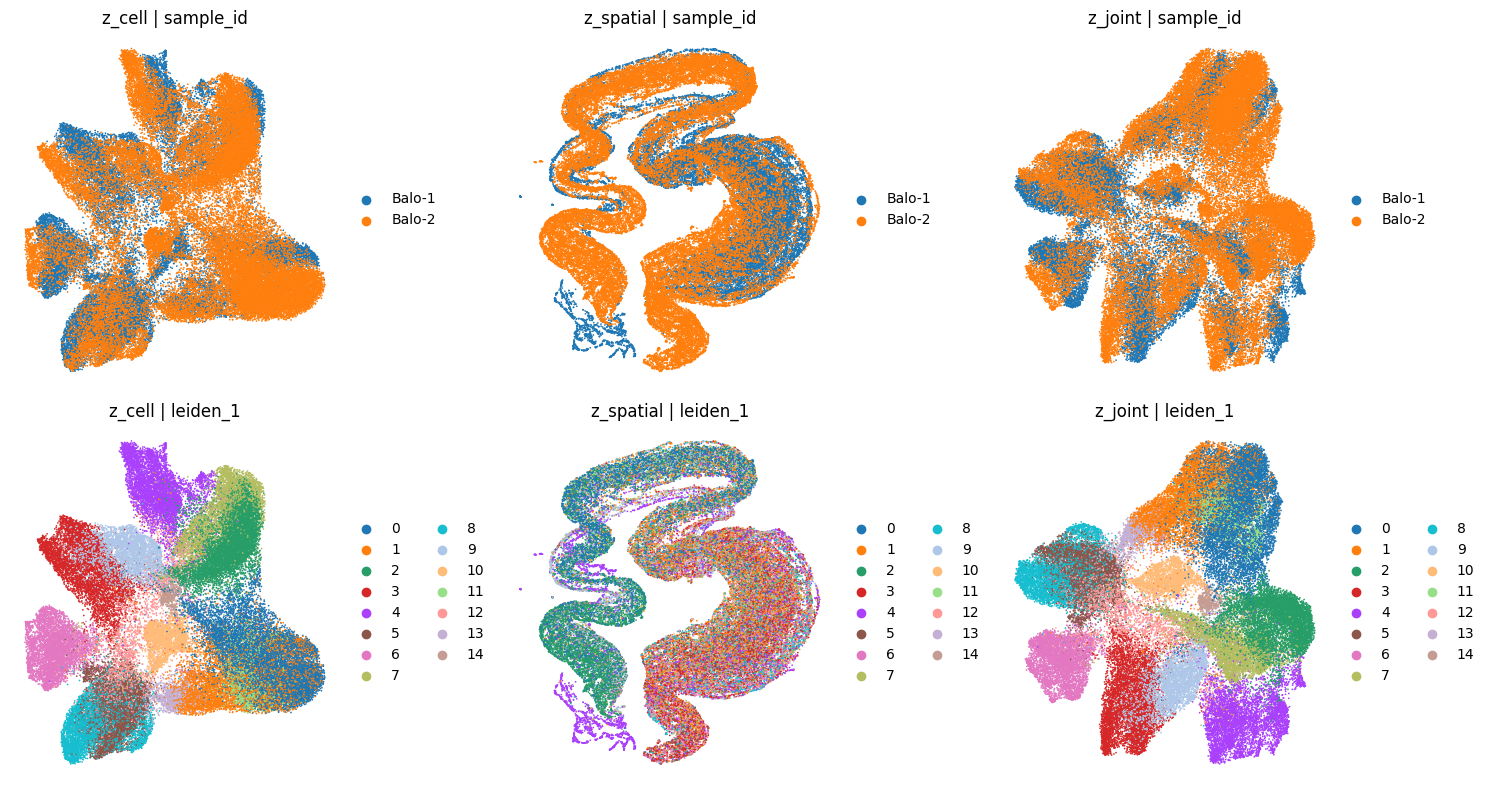

In [7]:
color_by = label_columns + ["leiden_1"]
color_by = [c for c in color_by if c in adata.obs.columns]

fig, axes = plt.subplots(
    nrows=len(color_by),
    ncols=len(latent_map),
    figsize=(5 * len(latent_map), 4 * len(color_by)),
    squeeze=False,
)
for r, color in enumerate(color_by):
    for c, (name, _) in enumerate(latent_map.items()):
        sc.pl.embedding(adata, basis=f"umap_{name}", color=color,
                        ax=axes[r, c], show=False, frameon=False,
                        title=f"{name} | {color}", size=6)
plt.tight_layout()
plt.savefig(OUT_DIR / "umap-overview.png", dpi=120, bbox_inches="tight")
plt.show()

## Niche discovery

Strategy:
1. Build a Delaunay spatial graph (per-sample, removes long edges with cellcharter).
2. Aggregate `X_z_joint` over 3 neighbourhood layers → captures both cell identity and spatial context in a smoothed, position-aware vector.
3. GMM on the aggregated embedding — Gaussian components are the right model for a VAE latent space.
4. Choose k via BIC (lower = better fit relative to complexity).

In [8]:
import squidpy as sq
import cellcharter as cc

# Build per-sample Delaunay graph for neighbour aggregation.
# library_key ensures no cross-sample edges.
sq.gr.spatial_neighbors(
    adata,
    library_key="sample_id",
    coord_type="generic",
    delaunay=True,
)
cc.gr.remove_long_links(adata)
print("Spatial graph built and long links removed.")

INFO     Creating graph using `generic` coordinates and `None` transform and `2` libraries.                        
Spatial graph built and long links removed.


In [9]:
# Aggregate z_joint over 3 neighbourhood hops.
# n_layers=3 captures ~2-3 cell diameters of context in Xenium data.
# Result stored in adata.obsm['X_niche_input'].
cc.gr.aggregate_neighbors(
    adata,
    n_layers=3,
    use_rep="X_z_joint",
    out_key="X_niche_input",
)
print("Aggregated embedding shape:", adata.obsm["X_niche_input"].shape)

  0%|          | 0/4 [00:00<?, ?it/s]

Aggregated embedding shape: (64191, 256)


k= 5  BIC=-120,097,059  AIC=-121,600,475
k= 8  BIC=-120,016,450  AIC=-122,421,922
k=10  BIC=-119,542,445  AIC=-122,549,286
k=12  BIC=-119,189,283  AIC=-122,797,495
k=15  BIC=-118,493,751  AIC=-123,004,018
k=20  BIC=-117,193,472  AIC=-123,207,165


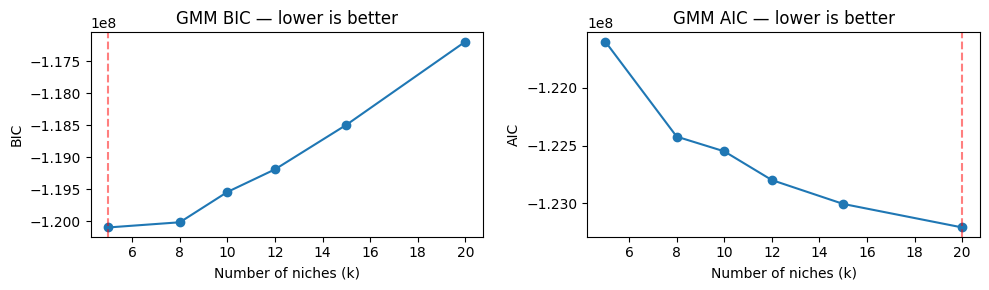


BIC-optimal k = 5


In [10]:
from sklearn.mixture import GaussianMixture

X = adata.obsm["X_niche_input"]
K_RANGE = [5, 8, 10, 12, 15, 20]
gmm_stats = []

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=SEED,
        n_init=3,
    )
    gmm.fit(X)
    gmm_stats.append({"k": k, "bic": gmm.bic(X), "aic": gmm.aic(X)})
    print(f"k={k:2d}  BIC={gmm.bic(X):,.0f}  AIC={gmm.aic(X):,.0f}")

gmm_stats_df = pd.DataFrame(gmm_stats)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, metric in zip(axes, ["bic", "aic"]):
    ax.plot(gmm_stats_df["k"], gmm_stats_df[metric], marker="o")
    ax.set_xlabel("Number of niches (k)")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"GMM {metric.upper()} — lower is better")
    ax.axvline(gmm_stats_df.loc[gmm_stats_df[metric].idxmin(), "k"], color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / "gmm-bic-aic.png", dpi=120, bbox_inches="tight")
plt.show()

best_k = int(gmm_stats_df.loc[gmm_stats_df["bic"].idxmin(), "k"])
print(f"\nBIC-optimal k = {best_k}")

In [11]:
# Fit final GMM at BIC-optimal k.
# Also keep one alternative (best_k + a few more) for comparison.
K_FINAL = [best_k, min(best_k + 3, 25)]

for k in K_FINAL:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=SEED,
        n_init=5,          # more inits for the final fit
    )
    labels = gmm.fit_predict(X)
    key = f"navi_niche_{k}"
    adata.obs[key] = pd.Categorical(labels.astype(str))
    print(f"k={k}: stored as obs['{key}']")

k=5: stored as obs['navi_niche_5']
k=8: stored as obs['navi_niche_8']


## Validate niches are cross-sample

Each niche should contain cells from both samples. A niche that is >90% from one sample is either:
- A genuine condition-specific structure (biologically interesting — keep it, note it)
- A sign of sample leakage (would show up as high sample predictability from z_cell too)

The key number to compare against: global sample frequency (~43% Balo-1, ~57% Balo-2).

In [12]:
niche_key = f"navi_niche_{best_k}"

# Fraction of each niche from each sample
composition = pd.crosstab(
    adata.obs[niche_key],
    adata.obs["sample_id"],
    normalize="index",
).round(3)

# Global sample frequencies for reference
global_freq = adata.obs["sample_id"].value_counts(normalize=True).sort_index()
print("Global sample frequency:")
print(global_freq.to_string())
print(f"\nNiche composition (row = niche, col = sample fraction):")
print(composition.to_string())

# Flag niches that are highly skewed (>80% from one sample)
max_frac = composition.max(axis=1)
skewed = max_frac[max_frac > 0.80]
if len(skewed):
    print(f"\nHighly skewed niches (>80% one sample) — may be condition-specific:")
    print(skewed.to_string())
else:
    print("\nAll niches well-represented across samples. ✓")

Global sample frequency:
sample_id
Balo-1    0.427085
Balo-2    0.572915

Niche composition (row = niche, col = sample fraction):
sample_id     Balo-1  Balo-2
navi_niche_5                
0              0.559   0.441
1              0.138   0.862
2              0.727   0.273
3              0.677   0.323
4              0.000   1.000

Highly skewed niches (>80% one sample) — may be condition-specific:
navi_niche_5
1    0.862
4    1.000


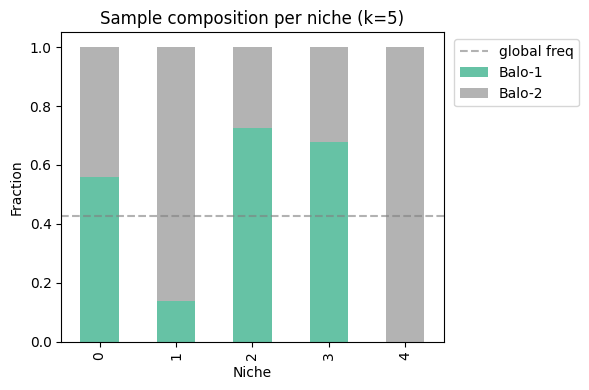

In [13]:
# Stacked bar: sample composition per niche
ax = composition.plot(
    kind="bar",
    stacked=True,
    figsize=(max(6, best_k * 0.7), 4),
    colormap="Set2",
)
ax.axhline(float(global_freq.iloc[0]), linestyle="--", color="grey", alpha=0.6, label="global freq")
ax.set_xlabel("Niche")
ax.set_ylabel("Fraction")
ax.set_title(f"Sample composition per niche (k={best_k})")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / f"niche-sample-composition-k{best_k}.png", dpi=120, bbox_inches="tight")
plt.show()

## Visualise niches on tissue sections

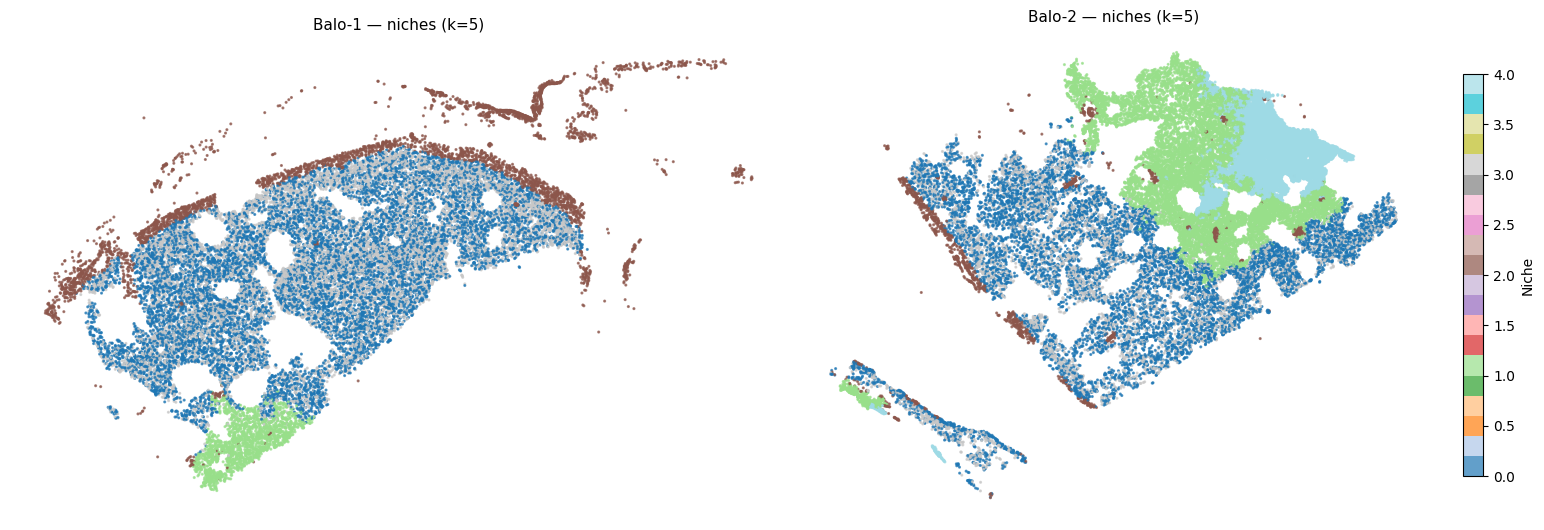

In [14]:
samples = adata.obs["sample_id"].unique().tolist()
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(samples),
    figsize=(8 * len(samples), 7),
    squeeze=False,
)

for col, sample in enumerate(samples):
    ax = axes[0, col]
    mask = adata.obs["sample_id"] == sample
    sub = adata[mask]
    coords = sub.obsm["spatial"]
    labels = sub.obs[niche_key].astype(int).to_numpy()
    scatter = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=labels,
        cmap="tab20",
        s=1.5,
        alpha=0.7,
        vmin=0,
        vmax=best_k - 1,
    )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(f"{sample} — niches (k={best_k})", fontsize=11)
    ax.axis("off")

plt.colorbar(scatter, ax=axes[0, -1], label="Niche", shrink=0.6)
plt.tight_layout()
plt.savefig(OUT_DIR / f"tissue-niches-k{best_k}.png", dpi=150, bbox_inches="tight")
plt.show()

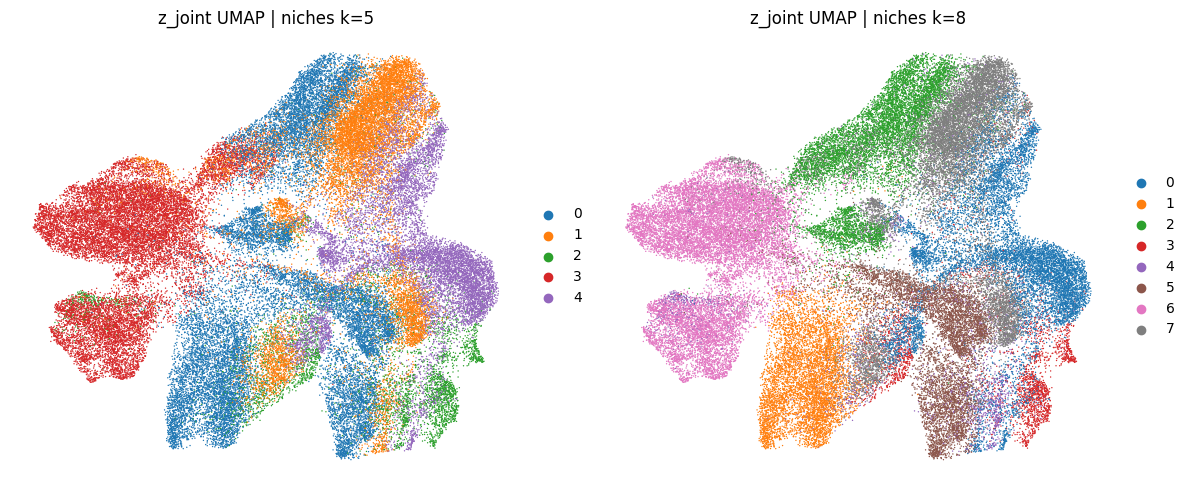

In [15]:
# UMAP of z_joint coloured by niche — confirms niches are spatially organised in latent space
fig, axes = plt.subplots(1, len(K_FINAL), figsize=(6 * len(K_FINAL), 5), squeeze=False)
for col, k in enumerate(K_FINAL):
    sc.pl.embedding(
        adata,
        basis="umap_z_joint",
        color=f"navi_niche_{k}",
        ax=axes[0, col],
        show=False,
        frameon=False,
        title=f"z_joint UMAP | niches k={k}",
        size=4,
    )
plt.tight_layout()
plt.savefig(OUT_DIR / "umap-niches.png", dpi=120, bbox_inches="tight")
plt.show()

## Differential niche abundance

The proportion of cells in each niche differs between samples — this is the compositional finding.
Niches that are enriched in one sample vs. the other are your disease-relevant spatial structures.

In [16]:
abundance = (
    adata.obs.groupby("sample_id")[niche_key]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
    .rename(columns={niche_key: "niche"})
)

# Pivot for easy comparison
abundance_wide = abundance.pivot(index="niche", columns="sample_id", values="fraction").fillna(0)

# Log2 fold change: positive = enriched in Balo-2, negative = enriched in Balo-1
samples_sorted = sorted(abundance_wide.columns)
if len(samples_sorted) == 2:
    s1, s2 = samples_sorted
    abundance_wide["log2fc"] = np.log2(
        (abundance_wide[s2] + 1e-6) / (abundance_wide[s1] + 1e-6)
    )
    abundance_wide = abundance_wide.sort_values("log2fc")

print(abundance_wide.round(4).to_string())
abundance_wide.to_csv(NICHE_CSV)
print(f"\nSaved to {NICHE_CSV}")

sample_id  Balo-1  Balo-2   log2fc
niche                             
2          0.1324  0.0370  -1.8391
3          0.3971  0.1410  -1.4941
0          0.4033  0.2369  -0.7677
1          0.0672  0.3140   2.2236
4          0.0000  0.2712  18.0489

Saved to /Users/christoffer/work/karolinska/development/NAVI/output/niche-analysis/niche-abundance.csv


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_71632/1198973039.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("sample_id")[niche_key]


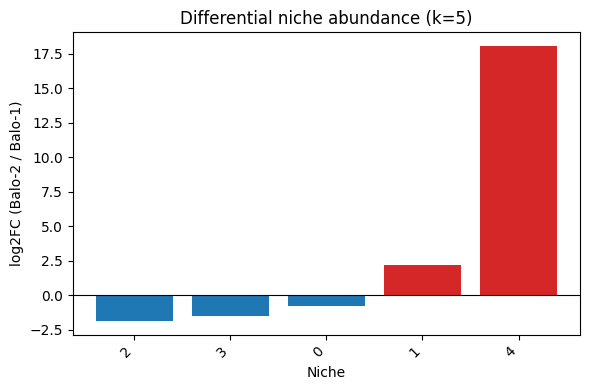

In [17]:
if "log2fc" in abundance_wide.columns:
    fig, ax = plt.subplots(figsize=(max(6, best_k * 0.6), 4))
    colors = ["#d62728" if v > 0 else "#1f77b4" for v in abundance_wide["log2fc"]]
    ax.bar(abundance_wide.index.astype(str), abundance_wide["log2fc"], color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Niche")
    ax.set_ylabel(f"log2FC ({s2} / {s1})")
    ax.set_title(f"Differential niche abundance (k={best_k})")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"niche-abundance-log2fc-k{best_k}.png", dpi=120, bbox_inches="tight")
    plt.show()

## Save

In [18]:
print("obsm keys:", [k for k in adata.obsm if k.startswith("X_z")])
print("niche obs keys:", [k for k in adata.obs if k.startswith("navi_niche")])
print("Graph metadata:", model.graph_metadata_)

adata.write_h5ad(OUTPUT_H5AD)
print(f"\nSaved h5ad    : {OUTPUT_H5AD}")

metrics_df.to_csv(METRICS_CSV, index=False)
print(f"Saved metrics : {METRICS_CSV}")

obsm keys: ['X_z_cell', 'X_z_spatial', 'X_z_joint']
niche obs keys: ['navi_niche_5', 'navi_niche_8']
Graph metadata: {'adjusted_k_per_sample': {np.str_('Balo-1'): 15, np.str_('Balo-2'): 15}, 'skipped_samples': []}

Saved h5ad    : /Users/christoffer/work/karolinska/development/NAVI/output/niche-analysis/navi-with-latents.h5ad
Saved metrics : /Users/christoffer/work/karolinska/development/NAVI/output/niche-analysis/embedding-metrics.csv
